# day 36 prep

first i need to look up the second derivative function that I wrote down:

```python
def doubled(function, x_value, stepSize):
    return (function(x_value+stepSize)-2*function(x_value)+function(x_value-stepSize))/(stepSize**2)
```

Right so that confirms what we are doing in the partial differential equation section.

Next I need to code up how to solve the heat equation. This involves learning the FTCS Method which stands for Forward-Time Centered-Space. What this amounts to is combining the method we have used for solving the laplacian with Eulers method for solving differential equations.

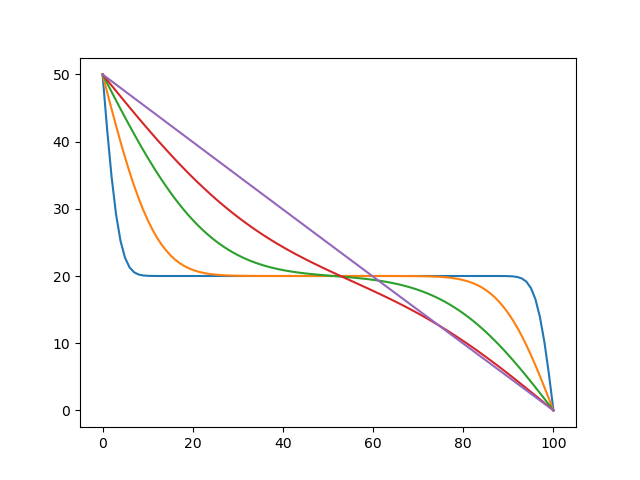

In [15]:
# first some constants

L = 0.01 # entire length
D = 4.25e-6 # thermal diffusivity
N = 100 # number of points to break up the length into a grid
a = L/N # grid spacing
dt = 1e-4 # time step


epsilon = dt/1000
fig0, ax0 = plt.subplots()


Tlow = 0.0 # low temp side
Thi = 50.0 # hi temp side
Ti = 20 # this is actually the initial temperature of the rod

# now for the time ticking by
# we want to plot this at some particular times
# but we don't want to store the temperature 
# profile at EVERY time. 
t1 = 0.01
t2 = 0.1
t3 = 0.4
t4 = 1.0
t5 = 10.0
tend = t5+epsilon

T = np.empty(N+1)
T[0] = Thi
T[N] = Tlow

# we need some kind of temperature to go in between
# this is like the initial temperature of the 
# entire rod
T[1:N] = Ti 

Tp = np.empty(N+1)
Tp[0] = Thi
Tp[N] = Tlow

t = 0
# just go ahead and define this constant here 
# to avoid recalculating it over and over
c = dt*D/(a*a) 

while t<tend:
    for i in range(1, N): # this is going to NOT change the last N+1 value
        # this is updating the temperature along the length of the rod
        Tp[i] = T[i] + c*(T[i+1]+T[i-1]-2*T[i])
    T, Tp = Tp, T
    t+=dt

    # we need to plot while this time is advancing, otherwise we will find 
    # what we already know: that the temperature becomes linear over time
    if np.abs(t-t1)<epsilon:
        ax0.plot(T)
    if np.abs(t-t2)<epsilon:
        ax0.plot(T)
    if np.abs(t-t3)<epsilon:
        ax0.plot(T)
    if np.abs(t-t4)<epsilon:
        ax0.plot(T)
    if np.abs(t-t5)<epsilon:
        ax0.plot(T)




# i think this one is a little better to understand

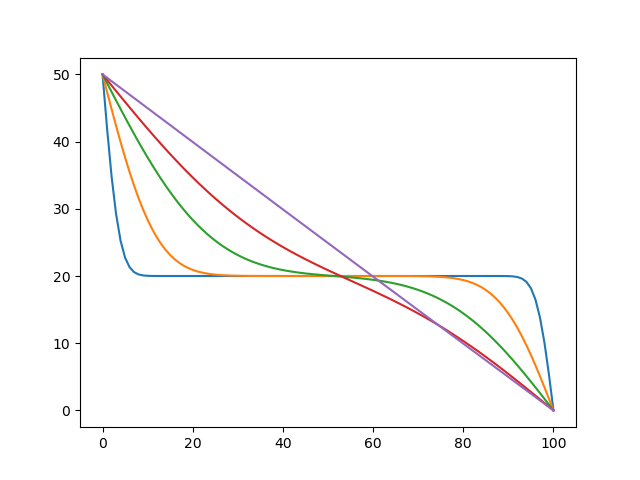

In [23]:
L = 0.01
D = 4.25e-6
N = 100
dx = L/N
dt = 1e-4
c = D*dt/dx**2

# boundary temps
Tlo = 0.0
Thi = 50.0
Ti = 20.0

# snapshot times
times = [0.01, 0.1, 0.4, 1.0, 10.0]
snapshots = []

T = np.ones(N+1)*Ti
T[0] = Thi
T[-1] = Tlo

t = 0.0

for target in times:
    while t < target:
        # forward-euler discrete laplacian
        for i in range(1, N): # this is going to NOT change the last N+1 value
            # this is updating the temperature along the length of the rod
            Tp[i] = T[i] + c*(T[i+1]+T[i-1]-2*T[i])
        T, Tp = Tp, T
        t+=dt
        # or we could replace that for loop with something better!
        # T[1:-1] += c*(T[2:] + T[:-2] - 2*T[1:-1])
        # t += dt
    snapshots.append(T.copy())

# plotting
fig, ax = plt.subplots()
for profile in snapshots:
    ax.plot(profile)

# additional questions: 

1. what happens when c gets bigger?
2. 